# Run BiSSGL

In [1]:
import os
import time
import gzip
import pickle
import warnings

%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np

from tqdm import TqdmSynchronisationWarning
warnings.simplefilter("ignore", TqdmSynchronisationWarning)

In [2]:
PATH_ROOT = "/Users/sijianfan/Documents/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/cdataset/noisy")
if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

In [3]:
filename_staged = os.path.join(PATH_DATA, "staged_dataset.gz")

filenames = {"input": "staged_dataset.gz", "output": "results_bissgl.gz"}

In [4]:
filename_input = os.path.join(PATH_DATA, filenames["input"])

filename_output = os.path.join(PATH_OUTPUT, filenames["output"])

In [5]:
if os.path.exists(filename_output):
    mdttm = time.strftime("%Y%m%d_%H%M%S")
    os.rename(
        filename_output,
        os.path.join(PATH_ARCHIVE, "%s%s" % (mdttm, filenames["output"])),
    )

In [6]:
from sgimc.utils import mc_split

In [7]:
from sgimc.utils import get_submatrix

In [8]:
import numpy as np


def get_metrics(real_score, predict_score):
    sorted_predict_score = np.array(
        sorted(list(set(np.array(predict_score).flatten())))
    )
    sorted_predict_score_num = len(sorted_predict_score)
    thresholds = sorted_predict_score[
        np.int32(sorted_predict_score_num * np.arange(1, 1000) / 1000)
    ]
    thresholds = np.mat(thresholds)
    thresholds_num = thresholds.shape[1]

    predict_score_matrix = np.tile(predict_score, (thresholds_num, 1))
    negative_index = np.where(predict_score_matrix < thresholds.T)
    positive_index = np.where(predict_score_matrix >= thresholds.T)
    predict_score_matrix[negative_index] = 0
    predict_score_matrix[positive_index] = 1
    TP = predict_score_matrix.dot(real_score.T)
    FP = predict_score_matrix.sum(axis=1) - TP
    FN = real_score.sum() - TP
    TN = len(real_score.T) - TP - FP - FN

    fpr = FP / (FP + TN)
    tpr = TP / (TP + FN)
    ROC_dot_matrix = np.mat(sorted(np.column_stack((fpr, tpr)).tolist())).T
    ROC_dot_matrix.T[0] = [0, 0]
    ROC_dot_matrix = np.c_[ROC_dot_matrix, [1, 1]]
    x_ROC = ROC_dot_matrix[0].T
    y_ROC = ROC_dot_matrix[1].T
    auc = 0.5 * (x_ROC[1:] - x_ROC[:-1]).T * (y_ROC[:-1] + y_ROC[1:])

    recall_list = tpr
    precision_list = TP / (TP + FP)
    PR_dot_matrix = np.mat(
        sorted(np.column_stack((recall_list, precision_list)).tolist())
    ).T
    PR_dot_matrix.T[0] = [0, 1]
    PR_dot_matrix = np.c_[PR_dot_matrix, [1, 0]]
    x_PR = PR_dot_matrix[0].T
    y_PR = PR_dot_matrix[1].T
    aupr = 0.5 * (x_PR[1:] - x_PR[:-1]).T * (y_PR[:-1] + y_PR[1:])

    f1_score_list = 2 * TP / (len(real_score.T) + TP - TN)
    accuracy_list = (TP + TN) / len(real_score.T)
    specificity_list = TN / (TN + FP)

    max_index = np.argmax(f1_score_list)
    f1_score = f1_score_list[max_index]
    accuracy = accuracy_list[max_index]
    specificity = specificity_list[max_index]
    recall = recall_list[max_index]
    precision = precision_list[max_index]
    return [aupr[0, 0], auc[0, 0], f1_score, accuracy, recall, specificity, precision]

In [9]:
random_state = np.random.RandomState(0x0BADCAFE)

In [10]:
from sgimc.utils import load, save

U, V, Y = load(filename_input)

Y = Y.astype(float)

In [11]:
dvlp_size, test_size = 0.9, 0.1

ind_dvlp, ind_test = next(
    mc_split(
        Y,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)

Y_test = get_submatrix(Y, ind_test)

## Load model

In [12]:
import sys

sys.path.append(PATH_ROOT)

from scripts.methods.BiSSGL.BiSSGLc import BiSSGL

## Implementation

In [46]:
from sklearn.model_selection import ParameterGrid

grid_dataset = ParameterGrid(
    {
        # "train_size": np.arange(0.1, 0.9, 0.1),
        "train_size": [0.81],
        "n_splits": [2],
    }
)

grid_model = ParameterGrid(
    {
        "tilde_lambda0": [500],
        "tilde_lambda1": [1],
        "lambda0": [500],
        "lambda1": [1],
        # "xi": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12],
        "xi": [3],
        "eta": [1e-6],
        "K": [50],
    }
)

# Notes:
# eta is good at 1e-8.

In [35]:
# U = np.eye(Y.shape[0])
# V = np.eye(Y.shape[1])

In [36]:
print(U.shape, V.shape)

(658, 1888) (409, 797)


In [47]:
from tqdm import tqdm
from sklearn.model_selection import ShuffleSplit, KFold
from sklearn.model_selection import train_test_split
from scipy.special import expit


results = []
for par_dtst in tqdm(grid_dataset):
    # prepare the train dataset: take the specified share from the beginnig of the index array
    ind_train_all, _ = train_test_split(
        ind_dvlp,
        shuffle=False,
        random_state=random_state,
        test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
    )

    # Run the experiment: the model
    for par_mdl in grid_model:  # tqdm.tqdm(, desc="cv %02d" % (cv,))
        Y_train = get_submatrix(Y, ind_train_all)

        # Y_train[Y_train == 0] = 0.5
        Y_train[Y_train == -1] = 0

        # set up the model
        xi, eta, tilde_lambda0, tilde_lambda1, lambda0, lambda1, K = (
            par_mdl["xi"],
            par_mdl["eta"],
            par_mdl["tilde_lambda0"],
            par_mdl["tilde_lambda1"],
            par_mdl["lambda0"],
            par_mdl["lambda1"],
            par_mdl["K"],
        )

        model = BiSSGL(
            Y=Y_train.toarray(),
            U=U,
            V=V,
            xi=xi,
            eta=eta,
            tilde_lambda0=tilde_lambda0,
            tilde_lambda1=tilde_lambda1,
            tilde_alpha=1 / K,
            tilde_beta=1,
            lambda0=lambda0,
            lambda1=lambda1,
            alpha=1 / K,
            beta=1,
            K=K,
            max_iter=5000,
            tol=1e-8,
        )

        # fit on the whole development dataset
        est_mu, est_A, est_B, logLik = model.optimization()

        # get the score
        prob_full = expit(U @ est_A @ est_B.T @ V.T)
        prob_test = get_submatrix(prob_full, ind_test)
        scores_test = get_metrics((Y_test.data + 1) / 2, prob_test.data)
        d1_test = sum(abs(est_A).max(axis=1) > 0)
        d2_test = sum(abs(est_B).max(axis=1) > 0)

        # record the results
        results.append(
            {
                "train_size": par_dtst["train_size"],
                "xi": par_mdl["xi"],
                "eta": par_mdl["eta"],
                "tilde_lambda0": par_mdl["tilde_lambda0"],
                "tilde_lambda1": par_mdl["tilde_lambda1"],
                "lambda0": par_mdl["lambda0"],
                "lambda1": par_mdl["lambda1"],
                "K": par_mdl["K"],
                "test_score": scores_test,
                "test_d1": d1_test,
                "test_d2": d2_test,
            }
        )

  0%|          | 0/1 [00:00<?, ?it/s]

Finished with iterations of 4999


100%|██████████| 1/1 [08:57<00:00, 537.98s/it]


In [48]:
results

[{'train_size': 0.81,
  'xi': 3,
  'eta': 1e-06,
  'tilde_lambda0': 500,
  'tilde_lambda1': 1,
  'lambda0': 500,
  'lambda1': 1,
  'K': 50,
  'test_score': [0.1505818284776756,
   0.759178622701518,
   0.0510741791649777,
   0.8260320291309032,
   0.5142857142857142,
   0.8288960551972402,
   0.026871401151631478],
  'test_d1': 812,
  'test_d2': 497}]

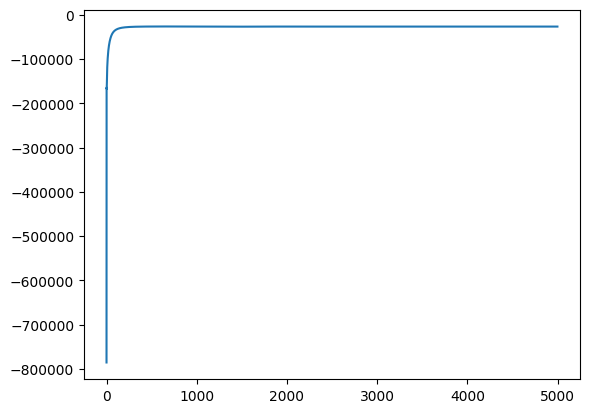

In [44]:
plt.plot(logLik)
# plt.stem(np.sort(abs(est_A).max(axis=1)))

In [ ]:
filename_output = "/Users/sijianfan/Documents/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_bissgl_identity.gz"

In [72]:
with gzip.open(filename_output, "wb+", 4) as fout:
    pickle.dump(results, fout)

---

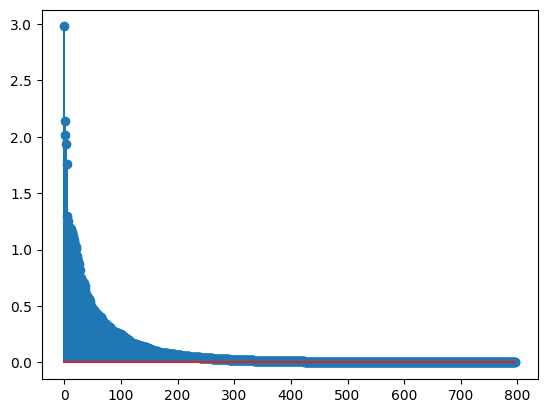

In [45]:
plt.stem(sorted(abs(est_B).max(axis=1), reverse=True))
plt.show()

---